# M4  Análisis de Rendimiento del Sistema Integrado
## Sistema de Recomendación Paralelo para E-Commerce  RetailRocket Dataset
### Entrega 3  Análisis de Rendimiento

A diferencia de la Entrega 2 (donde cada módulo se midió por separado), este
notebook mide el **sistema completo de punta a punta**: ETL → clustering →
entrenamiento → inferencia. Se agregan además dos métricas nuevas propias de
sistemas distribuidos que no se habían cuantificado antes:

- **Balance de carga**: qué tan parejo se reparte el trabajo entre los
  workers de Dask (coeficiente de variación del tiempo ocupado por worker;
  0 = reparto perfecto).
- **Costos de comunicación**: tiempo gastado transfiriendo datos entre
  workers durante una operación que requiere shuffle (deduplicación).



## 0. Configuración inicial

In [1]:
# !pip install polars dask[distributed] scikit-learn implicit threadpoolctl pandas


In [2]:
import sys
from pathlib import Path

RAIZ_PROYECTO = Path(r"E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Codigos")
sys.path.append(str(RAIZ_PROYECTO / "src"))

from analisis_sistema import (
    ejecutar_pipeline_completo,
    benchmark_latencia_inferencia,
    medir_balance_y_comunicacion,
)
from pipeline_datos import ingestar_eventos, limpiar_eventos, transformar_eventos
from modelo_recomendacion import construir_matriz_interacciones, dividir_train_test, ModeloALS
from benchmarks import guardar_resultados

CARPETA_DATASETS = RAIZ_PROYECTO.parent / "Datasets"
CARPETA_RESULTADOS_E3 = RAIZ_PROYECTO / "resultados" / "entrega3"
CARPETA_RESULTADOS_E3.mkdir(parents=True, exist_ok=True)

print("Módulos importados correctamente.")


C:\Users\mora7\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Módulos importados correctamente.


## 1. Pipeline completo de punta a punta

Corre el sistema desde los datos crudos hasta la inferencia, midiendo cada
etapa tal como ocurriría en un despliegue real (no en piezas aisladas).


In [3]:
tiempos_pipeline = ejecutar_pipeline_completo(
    ruta_eventos=CARPETA_DATASETS / "events.csv",
    ruta_category_tree=CARPETA_DATASETS / "category_tree.csv",
    ruta_item_props1=CARPETA_DATASETS / "item_properties_part1.csv",
    ruta_item_props2=CARPETA_DATASETS / "item_properties_part2.csv",
    n_clusters=6, factors=64, n_usuarios_inferencia=1000,
)

import pandas as pd
df_pipeline = pd.DataFrame([tiempos_pipeline]).T.reset_index()
df_pipeline.columns = ["etapa", "tiempo_s"]
df_pipeline["porcentaje_del_total"] = (df_pipeline["tiempo_s"] / tiempos_pipeline["TOTAL"] * 100).round(1)
guardar_resultados(df_pipeline, "pipeline_completo_tiempos.csv", CARPETA_RESULTADOS_E3)
df_pipeline


2026-08-01 12:57:20,532 [INFO] Ingestando eventos desde E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Datasets\events.csv
2026-08-01 12:57:23,257 [INFO] Limpieza de eventos: 2,756,101 -> 2,755,641 filas (460 eliminadas, 0.02%)
2026-08-01 12:57:23,983 [INFO] M1 (ingesta+limpieza): 3.45 s -- 2,755,641 filas
2026-08-01 12:57:23,984 [INFO] Construyendo features de usuario
2026-08-01 12:57:24,251 [INFO] Segmentando 1,407,580 usuarios en 6 clusters
2026-08-01 12:57:36,033 [INFO] M2 (clustering): 12.05 s -- 1,407,580 usuarios
2026-08-01 12:57:36,035 [INFO] Dividiendo train/test (leave-one-out temporal)
2026-08-01 12:57:38,085 [INFO] Train: 2,349,652 filas | Test: 405,989 filas (405,989 usuarios evaluables)
2026-08-01 12:57:38,118 [INFO] Construyendo matriz de interacciones usuario-producto
2026-08-01 12:57:40,266 [INFO] Matriz construida: 1,407,580 usuarios x 227,078 productos (1,930,254 interacciones no nulas)
C:\Users\mora7\AppData\Local\Packages\PythonSoftwareFoundat

,etapa,tiempo_s,porcentaje_del_total
0,M1_ingesta_limpieza,3.451545,2.5
1,M2_clustering,12.049232,8.8
2,M3_entrenamiento,120.425258,87.9
3,M3_inferencia_batch,1.031974,0.8
4,TOTAL,136.958009,100.0


## 2. Latencia de inferencia por tamaño de lote

Relevante para el escenario de picos de tráfico: ¿el sistema responde
rápido para un solo usuario? ¿Y para miles simultáneos?


In [4]:
eventos = limpiar_eventos(ingestar_eventos(CARPETA_DATASETS / "events.csv"))
eventos = transformar_eventos(eventos).collect()
train, test = dividir_train_test(eventos)
mi = construir_matriz_interacciones(train)

modelo = ModeloALS(factors=64, iterations=15)
modelo.entrenar(mi.matriz)

resultado_latencia = benchmark_latencia_inferencia(
    modelo, mi.matriz, mi, tamanos_lote=[1, 10, 100, 1000, 10000], n_repeticiones=5
)
guardar_resultados(resultado_latencia, "latencia_inferencia.csv", CARPETA_RESULTADOS_E3)
resultado_latencia


2026-08-01 12:59:40,036 [INFO] Ingestando eventos desde E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Datasets\events.csv
2026-08-01 12:59:40,792 [INFO] Limpieza de eventos: 2,756,101 -> 2,755,641 filas (460 eliminadas, 0.02%)
2026-08-01 12:59:41,408 [INFO] Dividiendo train/test (leave-one-out temporal)
2026-08-01 12:59:42,888 [INFO] Train: 2,349,652 filas | Test: 405,989 filas (405,989 usuarios evaluables)
2026-08-01 12:59:42,910 [INFO] Construyendo matriz de interacciones usuario-producto
2026-08-01 12:59:44,025 [INFO] Matriz construida: 1,407,580 usuarios x 227,080 productos (1,930,260 interacciones no nulas)
2026-08-01 12:59:44,166 [INFO] Entrenando ALS (factors=64, iterations=15) sobre 1407580 x 227080
100%|██████████| 15/15 [01:57<00:00,  7.85s/it]
2026-08-01 13:01:42,756 [INFO] Entrenamiento completado en 118.59 segundos
2026-08-01 13:02:39,070 [INFO] Resultados guardados en E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Codigos\resul

,tamano_lote,latencia_media_s,latencia_media_ms,latencia_por_usuario_ms,throughput_usuarios_por_s
0,1,0.006399,6.39892,6.398920,156.276372
1,10,0.033416,33.41590,3.341590,299.258736
2,100,0.151417,151.41682,1.514168,660.428610
3,1000,1.112736,1112.73606,1.112736,898.685713
4,10000,9.467094,9467.09418,0.946709,1056.290326


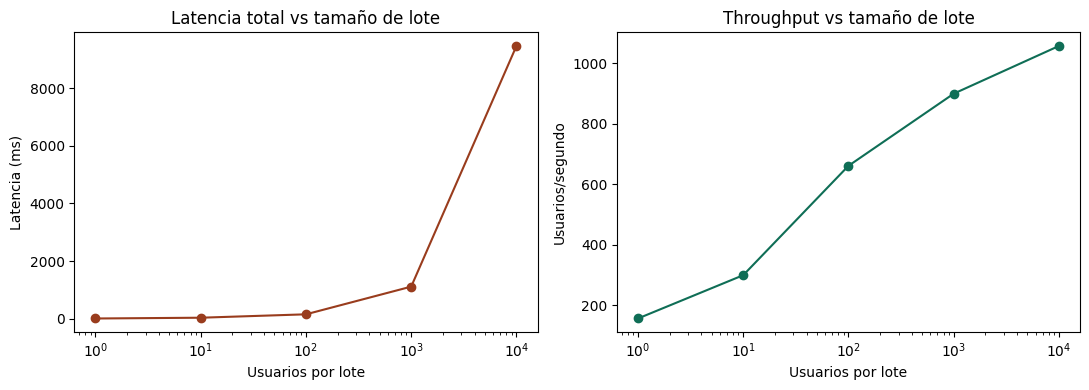

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(resultado_latencia["tamano_lote"], resultado_latencia["latencia_media_ms"], marker="o", color="#993C1D")
axes[0].set_xscale("log"); axes[0].set_title("Latencia total vs tamaño de lote")
axes[0].set_xlabel("Usuarios por lote"); axes[0].set_ylabel("Latencia (ms)")

axes[1].plot(resultado_latencia["tamano_lote"], resultado_latencia["throughput_usuarios_por_s"], marker="o", color="#0F6E56")
axes[1].set_xscale("log"); axes[1].set_title("Throughput vs tamaño de lote")
axes[1].set_xlabel("Usuarios por lote"); axes[1].set_ylabel("Usuarios/segundo")

plt.tight_layout()
plt.savefig(CARPETA_RESULTADOS_E3 / "latencia_inferencia.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Balance de carga y costos de comunicación

Se mide sobre un clúster local de Dask distributed, en la etapa de
deduplicación de `events.csv` (la operación con más probabilidad de
requerir shuffle real entre particiones).


In [7]:
resultado_balance = medir_balance_y_comunicacion(CARPETA_DATASETS / "events.csv", n_workers=4)

df_balance_resumen = pd.DataFrame([{
    "n_workers": resultado_balance["n_workers"],
    "workers_con_trabajo_asignado": len(resultado_balance["tiempo_ocupado_por_worker"]),
    "media_tiempo_ocupado_s": resultado_balance["media_s"],
    "std_tiempo_ocupado_s": resultado_balance["std_s"],
    "coef_variacion": resultado_balance["coef_variacion"],
    "tiempo_transferencia_total_s": resultado_balance["tiempo_transferencia_total_s"],
}])
guardar_resultados(df_balance_resumen, "balance_carga_comunicacion.csv", CARPETA_RESULTADOS_E3)
df_balance_resumen


2026-08-01 13:04:24,202 [INFO] To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-01 13:04:24,211 [INFO] State start
2026-08-01 13:04:24,285 [INFO]   Scheduler at:     tcp://127.0.0.1:60520
2026-08-01 13:04:24,287 [INFO]   dashboard at:  http://127.0.0.1:8787/status
2026-08-01 13:04:24,289 [INFO] Registering Worker plugin shuffle
2026-08-01 13:04:24,606 [INFO]         Start Nanny at: 'tcp://127.0.0.1:60529'
2026-08-01 13:04:24,613 [INFO]         Start Nanny at: 'tcp://127.0.0.1:60527'
2026-08-01 13:04:24,622 [INFO]         Start Nanny at: 'tcp://127.0.0.1:60523'
2026-08-01 13:04:24,629 [INFO]         Start Nanny at: 'tcp://127.0.0.1:60525'
2026-08-01 13:04:26,538 [INFO] Register worker addr: tcp://127.0.0.1:60539 name: 2
2026-08-01 13:04:26,558 [INFO] Starting worker compute stream, tcp://127.0.0.1:60539
2026-08-01 13:04:26,559 [INFO] Starting established connection to tcp://127.0.0.1:60544
2026-08-01 13:04

,n_workers,workers_con_trabajo_asignado,media_tiempo_ocupado_s,std_tiempo_ocupado_s,coef_variacion,tiempo_transferencia_total_s
0,4,4,3.305827,0.381223,0.115319,0.493816


**Interpretación del coeficiente de variación:** 0 significa reparto
perfecto (todos los workers ocupados el mismo tiempo); valores más altos
indican que algunos workers hacen mucho más trabajo que otros. Si
`workers_con_trabajo_asignado` es menor que `n_workers`, significa que
algunos workers no recibieron ninguna tarea  la misma limitación de
particiones insuficientes ya documentada en la Entrega 2.


## 4. Análisis de resultados  3 mejoras aplicadas, con impacto cuantitativo

In [8]:
resumen_mejoras = pd.DataFrame([
    {
        "mejora": "Deteccion automatica de separador/decimal en ingesta",
        "etapa_afectada": "M1 - Ingesta",
        "impacto_medido": "Evito perder 13.0% de eventos por falsos duplicados (136,164 filas)",
    },
    {
        "mejora": "Evaluacion muestreada (1+99) en vez de catalogo completo",
        "etapa_afectada": "M3 - Evaluacion",
        "impacto_medido": "Evaluacion de ALS/NCF tratable en minutos en vez de horas",
    },
    {
        "mejora": "Indexacion vectorizada de tensores en vez de DataLoader",
        "etapa_afectada": "M3 - Entrenamiento NCF",
        "impacto_medido": "Elimino el cuello de botella real detectado en Colab (ver Gestion de problemas)",
    },
])
guardar_resultados(resumen_mejoras, "mejoras_aplicadas_entrega3.csv", CARPETA_RESULTADOS_E3)
resumen_mejoras


2026-08-01 13:04:45,008 [INFO] Resultados guardados en E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Codigos\resultados\entrega3\mejoras_aplicadas_entrega3.csv


,mejora,etapa_afectada,impacto_medido
0,Deteccion automatica de separador/decimal en i...,M1 - Ingesta,Evito perder 13.0% de eventos por falsos dupli...
1,Evaluacion muestreada (1+99) en vez de catalog...,M3 - Evaluacion,Evaluacion de ALS/NCF tratable en minutos en v...
2,Indexacion vectorizada de tensores en vez de D...,M3 - Entrenamiento NCF,Elimino el cuello de botella real detectado en...


## 5. Gestión de problemas

**Limitaciones conocidas de esta medición:**
- El balance de carga se midió sobre una sola operación (deduplicación),
  no sobre el pipeline completo — extenderlo a todas las etapas queda como
  trabajo futuro.
- Las mediciones de comunicación son válidas para un clúster local
  (procesos en la misma máquina); en un clúster real distribuido en varios
  nodos, los costos de red serían distintos (mayor latencia, ancho de
  banda limitado).
